In [1]:
import numpy as np
import pandas as pd
from tqdm import trange
import matplotlib.pyplot as plt

In [2]:
data_path = '../../data/net_data/'
param_path = '../../bat_mod/result/param.xlsx'
seq_len = 30

导入数据

In [3]:
data1 = pd.read_excel(data_path + 'SP2_25C_FUDS/fuds_80.xlsx').values
data2 = pd.read_excel(data_path + 'SP2_25C_DST/dst_80.xlsx').values
data3 = pd.read_excel(data_path + 'SP2_25C_BJDST/bjdst_80.xlsx').values
data4 = pd.read_excel(data_path + 'SP2_25C_US06/us06_80.xlsx').values
data5 = pd.read_excel(data_path + 'OTHER_DATA/incre.xlsx').values

将数据按时间步划分

In [4]:
def split(data, seq_len):
    """将数据生成序列并按照比例划分为训练集和测试集,输入为pd，输出为ndarray"""
    """添加前一时刻的soc"""
    soc_pre = np.insert(data[:-1, -1], 0, data[0, -1]) 
    data1 = np.concatenate((soc_pre.reshape(-1, 1), data), axis=1) 
    """交替划分"""
    data2 = []
    for i in range(len(data1) - seq_len):
        data2.append(data1[i: i + seq_len, :])
    data3 = np.array(data2)
    """划分x和y"""
    x = data3[:, :, 1:-1]
    soc_pre = data3[:, 0, 0]
    y = data3[:, -1, -1]
    data_dict = {'ui数据': x, '前一时刻的soc': soc_pre, '当前soc': y}  
    return data_dict

In [5]:
data_dict1 = split(data1, seq_len=seq_len)
data_dict2 = split(data2, seq_len=seq_len)
data_dict3 = split(data3, seq_len=seq_len)
data_dict4 = split(data4, seq_len=seq_len)
data_dict5 = split(data5, seq_len=seq_len)

In [6]:
data_dict = {}
for key in data_dict1.keys():
    data_dict[key] = np.concatenate((data_dict1[key], \
                                data_dict2[key], \
                                data_dict3[key], \
                                data_dict4[key], \
                                data_dict5[key]), axis=0)

In [7]:
data_dict['ui数据'].shape

(209874, 30, 2)

给划分好的数据添加噪声

In [8]:
def add_noise_s(data, sigma_p, adp_noise):
    data = data.reshape(-1, 1)
    data_mea = np.zeros((data.shape[0], 1))
    if (adp_noise):
        """模式1: 输入百分比, 数据本身的大小 * 百分比 = sigma值"""
        for j in range(data.shape[0]):
            sigma = abs(data[j, 0] * sigma_p)
            data_mea[j, 0] = data[j, 0] + np.random.normal(0, sigma**2)
    else:
        """模式0: 直接输入sigma值"""
        data_mea = data + np.random.normal(0, sigma_p, size=data.shape)
    return data_mea

In [9]:
ui_noise = data_dict['ui数据'].copy()  
for i in trange(data_dict['ui数据'].shape[0]):    
    for j in range(data_dict['ui数据'].shape[-1]):
        ui_noise[i, :, j] = add_noise_s(data_dict['ui数据'][i, :, j], \
                                                 sigma_p=0.02, adp_noise=True).reshape(-1)

100%|███████████████████████████████| 209874/209874 [00:23<00:00, 9075.68it/s]


In [10]:
soc_noise = data_dict['前一时刻的soc'].copy()
soc_noise = add_noise_s(data_dict['前一时刻的soc'], sigma_p=0.01, adp_noise=False).reshape(-1)
for soc in soc_noise:
    if soc>1:
        soc = 1
    elif soc<0:
        soc = 0

soc添加噪声对比

In [11]:
noise1 = soc_noise - data_dict['前一时刻的soc']

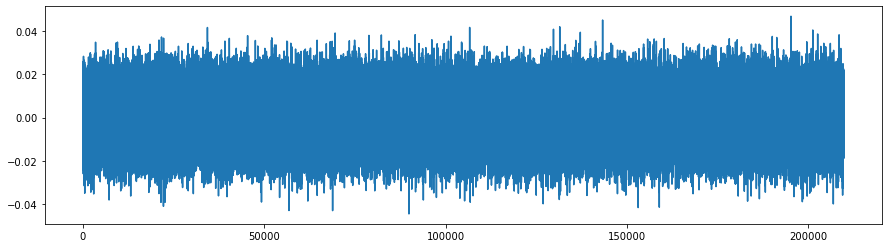

In [12]:
plt.figure(figsize=(15, 4))
plt.plot(noise1)
plt.show()

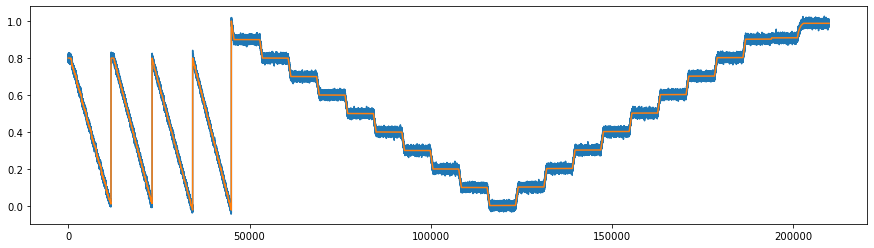

In [13]:
plt.figure(figsize=(15, 4))
plt.plot(soc_noise)
plt.plot(data_dict['前一时刻的soc'])
plt.show()

电流添加噪声对比

In [14]:
noise2 = ui_noise[:, 0, 0] - data_dict['ui数据'][:, 0, 0]

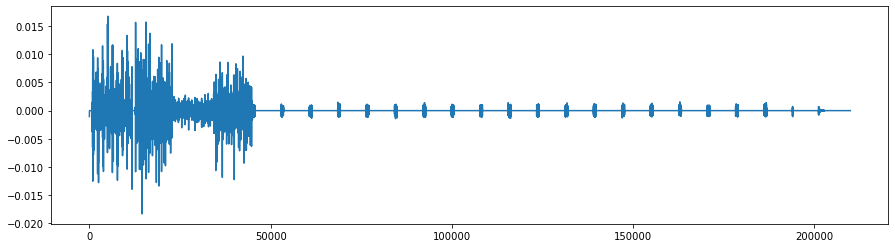

In [15]:
plt.figure(figsize=(15, 4))
plt.plot(noise2)
plt.show()

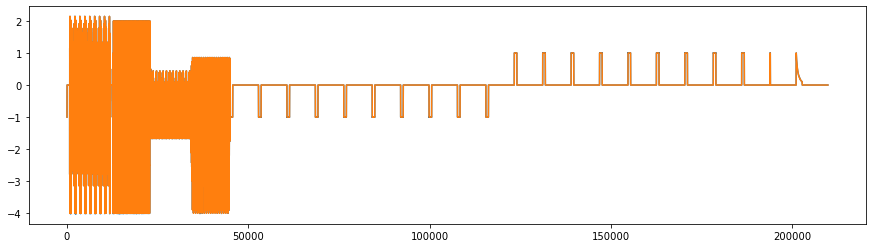

In [16]:
plt.figure(figsize=(15,4))
plt.plot(ui_noise[:, 0, 0])
plt.plot(data_dict['ui数据'][:, 0, 0])
plt.show()

电压添加噪声

In [17]:
noise3 = ui_noise[:, 0, 1] - data_dict['ui数据'][:, 0, 1]

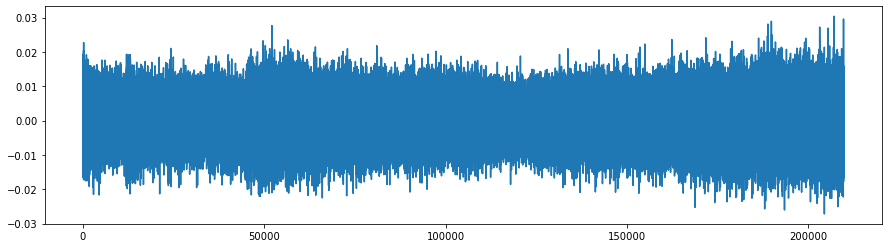

In [18]:
plt.figure(figsize=(15, 4))
plt.plot(noise3)
plt.show()

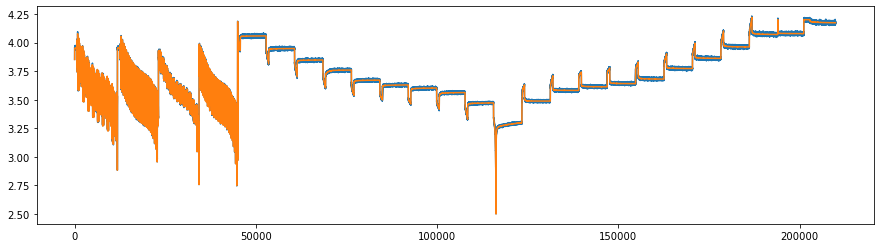

In [19]:
plt.figure(figsize=(15,4))
plt.plot(ui_noise[:, 0, 1])
plt.plot(data_dict['ui数据'][:, 0, 1])
plt.show()

In [20]:
data_noise_dict = {'ui数据': ui_noise, '前一时刻的soc': soc_noise, '当前soc': data_dict['当前soc']}

生成其他特征

In [21]:
from sfgen import sfgen

In [22]:
featurel = []
for i in trange(data_noise_dict['前一时刻的soc'].shape[0]):
    featurel.append(sfgen(data_noise_dict['前一时刻的soc'][i], param_path=param_path, seq_len=seq_len))    
featurea = np.array(featurel)

100%|████████████████████████████████| 209874/209874 [09:04<00:00, 385.79it/s]


In [23]:
featurea.shape

(209874, 30, 6)

划分训练集和测试集

In [24]:
y = np.repeat(data_dict['当前soc'].reshape(-1, 1), repeats=seq_len, axis=1)

In [25]:
y = y.reshape(-1, seq_len, 1)

In [26]:
y.shape

(209874, 30, 1)

In [27]:
xy = np.concatenate((ui_noise, featurea, y), axis=2)

In [28]:
np.random.shuffle(xy)

In [29]:
split_p = int(xy.shape[0] * 0.75)

In [30]:
train_x = xy[:split_p, :, :-1]
train_y = xy[:split_p, 0, -1]
test_x = xy[split_p:, :, :-1]
test_y = xy[split_p:, 0, -1]

归一化

In [31]:
maxi = np.max(train_x, axis=(0, 1))
mini = np.min(train_x, axis=(0, 1))
norm_dict = {'max': maxi, 'min': mini}

In [32]:
from norm import norm

In [33]:
train_x_nm = norm(train_x, norm_dict)
test_x_nm = norm(test_x, norm_dict)

In [34]:
xy_dict = {'train_x': train_x_nm, 'train_y': train_y, 'test_x': test_x_nm, 'test_y': test_y}

将本次训练的关键数据保存下来

In [35]:
save_path = '../trained_model/model1/'

In [36]:
np.save(save_path + 'norm_dict.npy', norm_dict)
np.save(save_path + 'xy_dict.npy', xy_dict)
np.save(save_path + 'data_noise_dict.npy', data_noise_dict)